# V4 Quantum Portfolio ? Report & Visualization

Adapted from `archive/PortfolioReport.ipynb` for the V4 Ultimate strategy.

Sections:
1. **Calibration Summary** ? phase params, regime, OOS validity, basis weights
2. **Quantum Wave Function** ? |?|? amplitude bar chart
3. **Z-score Rebalancing Signals** ? cointegration spread
4. **Sector Allocation** ? pie + bar
5. **Top Holdings** ? V4 columns table
6. **Monte Carlo** ? 1 000 paths ? 252 days
7. **Portfolio vs S&P 500** ? cumulative, vol, drawdown, distribution
8. **Risk Metrics** ? Sharpe, Sortino, VaR, Calmar
9. **Full Composite Report** ? combined 20?16 figure

All PNGs saved to `../output/v3/reports/`

In [1]:
import sys
sys.path.insert(0, '../src')

import os, json, glob, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import yfinance as yf
from datetime import datetime

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

REPORT_DIR = '../output/v3/reports'
os.makedirs(REPORT_DIR, exist_ok=True)

print(f"Report Date : {datetime.now().strftime('%Y-%m-%d %H:%M')}")
print(f"Output dir  : {os.path.abspath(REPORT_DIR)}")

Report Date : 2026-03-18 23:10
Output dir  : c:\Users\maxim\OneDrive\Bureau\Python\v4_ultimate\output\v3\reports


In [2]:
# Load V4 portfolio (ultimate_portfolio_*.csv)
portfolio_files = sorted(
    glob.glob('../output/v3/ultimate_portfolio_*.csv'),
    key=os.path.getmtime, reverse=True
)

if portfolio_files:
    latest = portfolio_files[0]
    portfolio = pd.read_csv(latest)
    if 'weight' in portfolio.columns:
        portfolio['weight'] = pd.to_numeric(portfolio['weight'], errors='coerce')
    print(f"Loaded  : {latest}")
    print(f"Holdings: {len(portfolio)}")
    print(f"Total wt: {portfolio['weight'].sum()*100:.1f}%")
else:
    print("No ultimate_portfolio_*.csv found ? run StockPickerV4_Ultimate.ipynb first.")
    portfolio = None

portfolio.head() if portfolio is not None else None

Loaded  : ../output/v3\ultimate_portfolio_03_18_2026.csv
Holdings: 17
Total wt: 100.0%


,ticker,weight,sector,sortino,win_rate,max_dd,momentum,vol_60,psi_sq,regime,zscore,psi_percentile
0,EXAS,0.066624,Healthcare,0.745286,0.555556,-0.592993,0.500137,0.027777,0.359853,BULL,0.0,100.000000
1,CFLT,0.066624,Technology,0.581362,0.472222,-0.594856,0.308692,0.040864,0.242943,BULL,0.0,99.408553
2,VCIC,0.066624,Financial,0.207018,0.764706,-0.115930,-0.000913,0.041105,0.223326,BULL,0.0,99.044586
3,TXNM,0.066624,Utilities,0.514011,0.583333,-0.266644,0.021400,0.040096,0.194125,BULL,0.0,97.679709
4,PRA,0.066624,Financial,0.508023,0.583333,-0.426842,0.021332,0.048874,0.193014,BULL,0.0,97.588717


In [3]:
cal_path = '../output/v3/calibration_meta.json'
if os.path.exists(cal_path):
    with open(cal_path) as f:
        cal_meta = json.load(f)
    print(f"Run     : {cal_meta.get('run_timestamp','N/A')[:19]}")
    print(f"Regime  : {cal_meta.get('regime')}")
    print(f"Phase   : a={cal_meta.get('best_a')}  b={cal_meta.get('best_b')}")
    print(f"OOS     : {cal_meta.get('oos_valid')}")
    print(f"Holdings: {cal_meta.get('n_holdings')} / AUM ${cal_meta.get('aum',0):,.0f}")
else:
    print("calibration_meta.json not found.")
    cal_meta = {}

Run     : 2026-03-18T23:09:09
Regime  : BULL
Phase   : a=2.0  b=0.975
OOS     : False
Holdings: 17 / AUM $10,000,000


In [4]:
prices = None; returns = None

if portfolio is not None:
    tickers = portfolio['ticker'].tolist()
    all_tickers = tickers + ['SPY']
    print(f"Downloading {len(all_tickers)} symbols...")
    raw = yf.download(all_tickers, period='1y', progress=False)
    if not raw.empty:
        if isinstance(raw.columns, pd.MultiIndex):
            lvl0 = raw.columns.get_level_values(0)
            col  = 'Close' if 'Close' in lvl0 else lvl0[0]
            prices = raw[col].copy()
        else:
            prices = raw[['Close' if 'Close' in raw.columns else raw.columns[0]]].copy()
            prices.columns = all_tickers[:1]
        prices  = prices.dropna(axis=1, how='all').dropna(axis=0, how='all')
        returns = prices.pct_change().dropna()
        missing = set(all_tickers) - set(prices.columns)
        if missing:
            print(f"Missing {len(missing)} tickers (e.g. {list(missing)[:5]})")
        print(f"Range: {prices.index[0].date()} to {prices.index[-1].date()} ({len(prices)} days)")

Range: 2025-03-19 to 2026-03-18 (251 days)


## 1. Calibration Summary

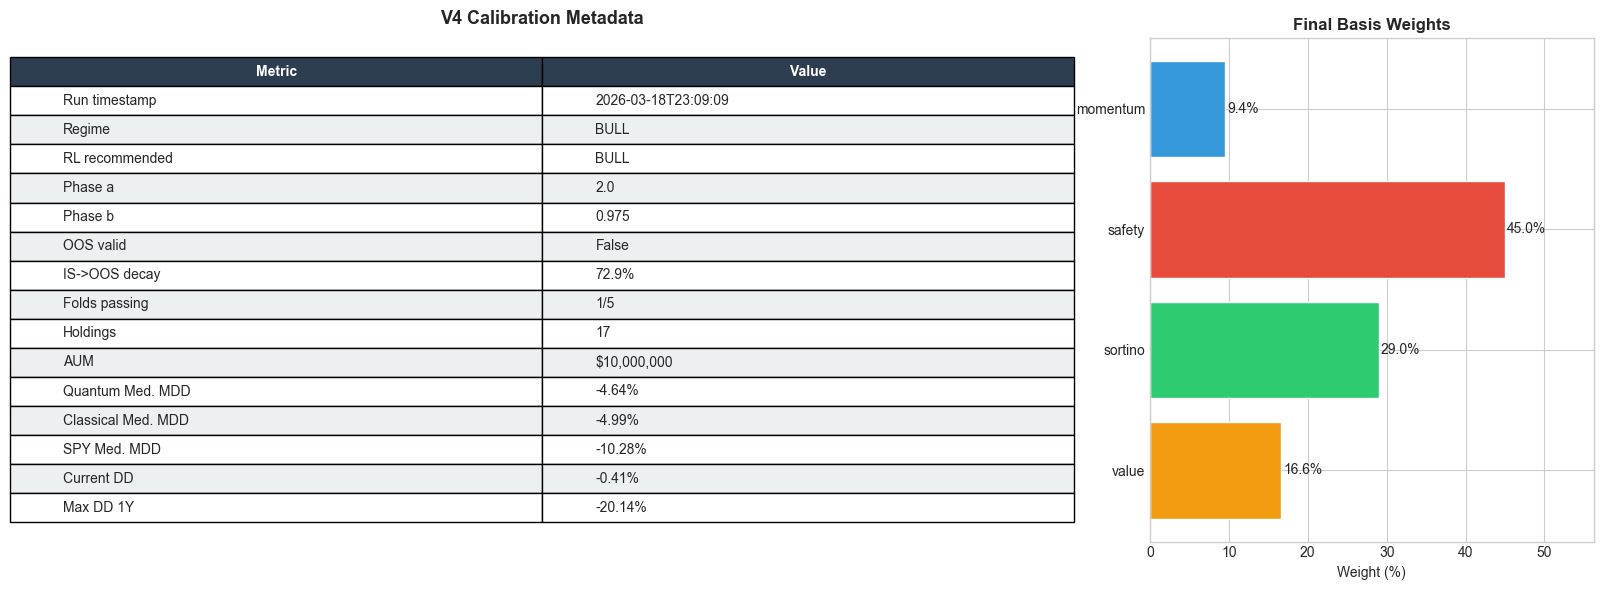

Saved: v4_calibration_summary.png


In [5]:
if cal_meta:
    dd_mc   = cal_meta.get('drawdown', {})
    dd_hist = cal_meta.get('drawdown_hist', {})
    fbw     = cal_meta.get('final_basis_weights', {})

    rows = [
        ('Run timestamp',      cal_meta.get('run_timestamp','N/A')[:19]),
        ('Regime',             cal_meta.get('regime','N/A')),
        ('RL recommended',     cal_meta.get('rl_recommended','N/A')),
        ('Phase a',            str(cal_meta.get('best_a','N/A'))),
        ('Phase b',            str(cal_meta.get('best_b','N/A'))),
        ('OOS valid',          str(cal_meta.get('oos_valid'))),
        ('IS->OOS decay',      f"{cal_meta.get('avg_decay_pct',0):.1f}%"),
        ('Folds passing',      f"{cal_meta.get('n_folds_pass',0)}/5"),
        ('Holdings',           str(cal_meta.get('n_holdings','N/A'))),
        ('AUM',                f"${cal_meta.get('aum',0):,.0f}"),
        ('Quantum Med. MDD',   f"{dd_mc.get('quantum_median_mdd','N/A')}%"),
        ('Classical Med. MDD', f"{dd_mc.get('classical_median_mdd','N/A')}%"),
        ('SPY Med. MDD',       f"{dd_mc.get('spy_median_mdd','N/A')}%"),
        ('Current DD',         f"{dd_hist.get('current_dd','N/A')}%"),
        ('Max DD 1Y',          f"{dd_hist.get('max_dd_1y','N/A')}%"),
    ]
    meta_df = pd.DataFrame(rows, columns=['Metric', 'Value'])

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), gridspec_kw={'width_ratios':[2,1]})

    ax = axes[0]; ax.axis('off')
    t = ax.table(cellText=meta_df.values, colLabels=meta_df.columns,
                 cellLoc='left', loc='center', colColours=['#2C3E50','#2C3E50'])
    t.auto_set_font_size(False); t.set_fontsize(10); t.scale(1.2, 1.6)
    for j in range(2): t[(0,j)].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(meta_df)+1):
        c = '#ECF0F1' if i%2==0 else 'white'
        for j in range(2): t[(i,j)].set_facecolor(c)
    ax.set_title('V4 Calibration Metadata', fontsize=13, fontweight='bold', pad=10)

    ax2 = axes[1]
    if fbw:
        ks = list(fbw.keys()); vs = [fbw[k]*100 for k in ks]
        colors = ['#3498DB','#E74C3C','#2ECC71','#F39C12']
        bars = ax2.barh(ks[::-1], vs[::-1], color=colors[:len(ks)][::-1], edgecolor='white')
        ax2.set_xlabel('Weight (%)'); ax2.set_title('Final Basis Weights', fontsize=12, fontweight='bold')
        for bar, v in zip(bars, vs[::-1]):
            ax2.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=10)
        ax2.set_xlim(0, max(vs)*1.25)
    else:
        ax2.text(0.5,0.5,'No basis weights', ha='center', va='center', transform=ax2.transAxes); ax2.axis('off')

    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/v4_calibration_summary.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print(f"Saved: v4_calibration_summary.png")
else:
    print("No calibration metadata ? skipping.")

## 2. Quantum Wave Function ? |?|? Amplitudes

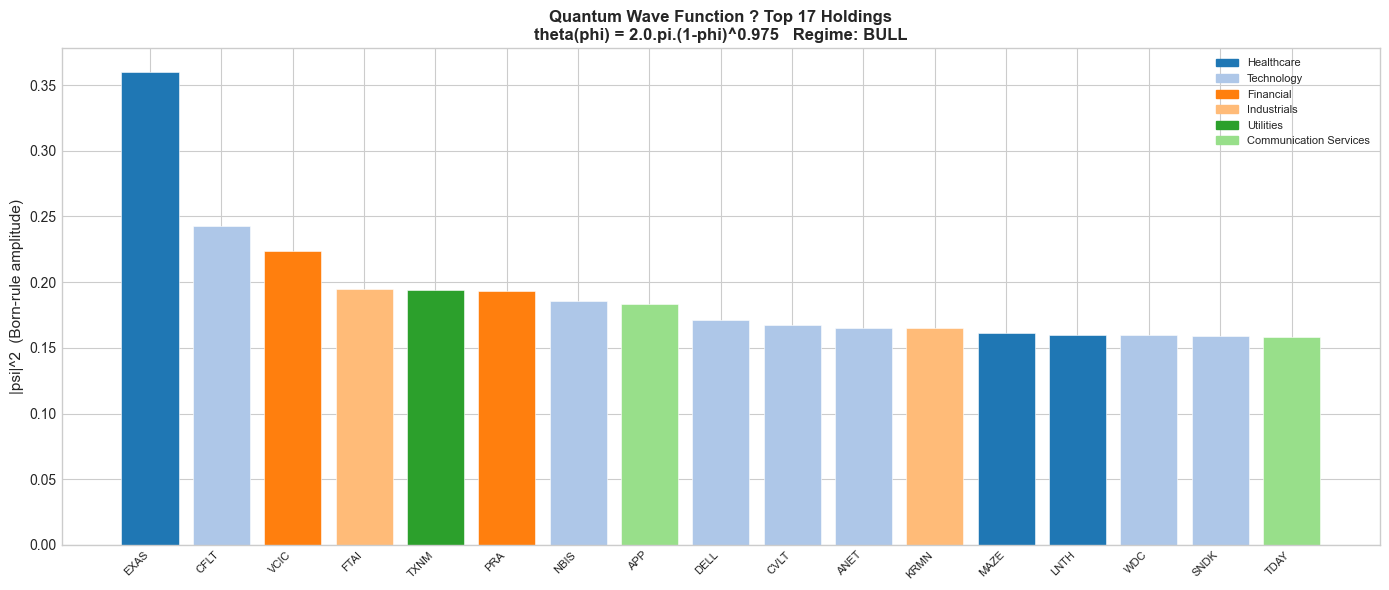

Saved: v4_wave_amplitudes_report.png


In [6]:
if portfolio is not None and 'psi_sq' in portfolio.columns:
    from matplotlib.patches import Patch
    top_n = min(40, len(portfolio))
    df_psi = portfolio.nlargest(top_n, 'psi_sq').copy()
    sectors = df_psi['sector'].unique() if 'sector' in df_psi.columns else []
    cmap    = plt.cm.tab20.colors
    sec_c   = {s: cmap[i % len(cmap)] for i, s in enumerate(sectors)}
    bar_c   = [sec_c.get(s, 'steelblue') for s in df_psi.get('sector', pd.Series([''] * len(df_psi)))]

    fig, ax = plt.subplots(figsize=(14, 6))
    ax.bar(df_psi['ticker'], df_psi['psi_sq'], color=bar_c, edgecolor='white', linewidth=0.4)
    ax.set_ylabel('|psi|^2  (Born-rule amplitude)', fontsize=11)
    a_val = cal_meta.get('best_a','?'); b_val = cal_meta.get('best_b','?')
    ax.set_title(f'Quantum Wave Function ? Top {top_n} Holdings\n'
                 f'theta(phi) = {a_val}.pi.(1-phi)^{b_val}   Regime: {cal_meta.get("regime","?")}',
                 fontsize=12, fontweight='bold')
    plt.xticks(rotation=45, ha='right', fontsize=8)
    if len(sectors):
        handles = [Patch(color=sec_c[s], label=s) for s in sectors]
        ax.legend(handles=handles, loc='upper right', fontsize=8, ncol=max(1, len(sectors)//5))
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/v4_wave_amplitudes_report.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_wave_amplitudes_report.png")
else:
    print("No psi_sq column ? skipping.")

## 3. Z-score Rebalancing Signals

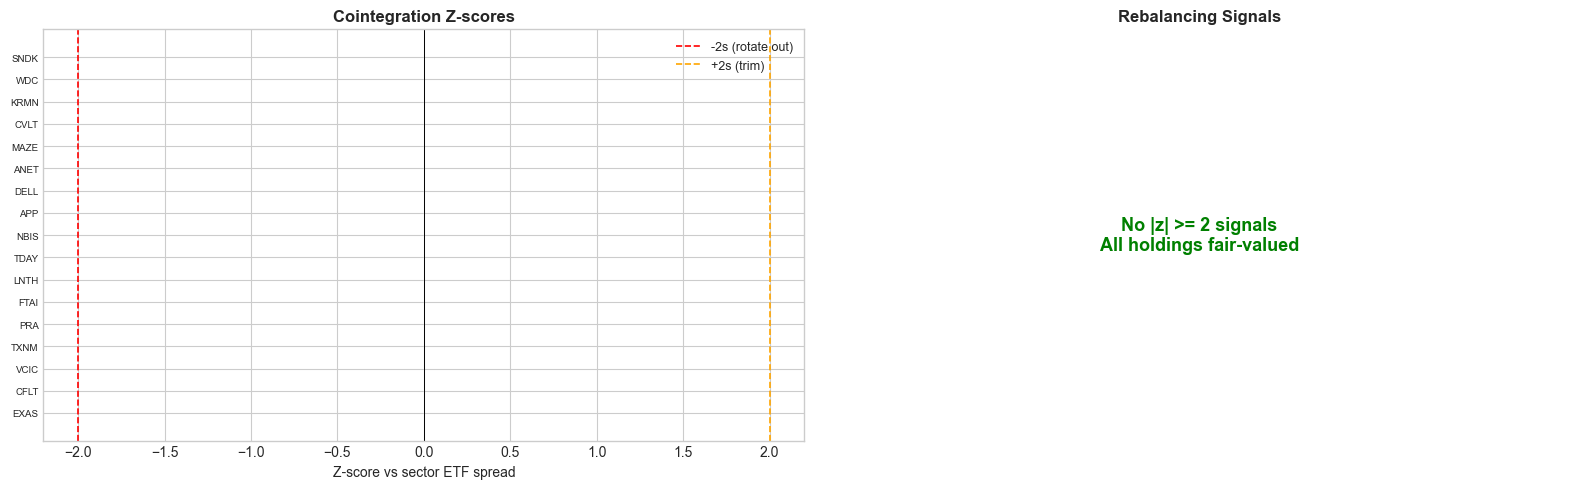

Saved: v4_zscore_signals_report.png


In [7]:
if portfolio is not None and 'zscore' in portfolio.columns:
    z = portfolio.copy()
    z['zscore'] = pd.to_numeric(z['zscore'], errors='coerce').fillna(0)

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    ax = axes[0]
    sz = z.sort_values('zscore', ascending=True)
    colors = ['#E74C3C' if v < -2 else ('#F39C12' if v > 2 else '#3498DB') for v in sz['zscore']]
    ax.barh(sz['ticker'], sz['zscore'], color=colors, edgecolor='white', linewidth=0.3)
    ax.axvline(-2, color='red',    linestyle='--', linewidth=1.2, label='-2s (rotate out)')
    ax.axvline(+2, color='orange', linestyle='--', linewidth=1.2, label='+2s (trim)')
    ax.axvline( 0, color='black',  linestyle='-',  linewidth=0.7)
    ax.set_xlabel('Z-score vs sector ETF spread')
    ax.set_title('Cointegration Z-scores', fontweight='bold')
    ax.legend(fontsize=9); ax.tick_params(axis='y', labelsize=7)

    ax2 = axes[1]; ax2.axis('off')
    flagged = z[z['zscore'].abs() >= 2.0].sort_values('zscore', key=abs, ascending=False)
    if flagged.empty:
        ax2.text(0.5, 0.5, 'No |z| >= 2 signals\nAll holdings fair-valued',
                 ha='center', va='center', transform=ax2.transAxes,
                 fontsize=13, color='green', fontweight='bold')
        ax2.set_title('Rebalancing Signals', fontweight='bold')
    else:
        cols_s = [c for c in ['ticker','sector','weight','zscore','psi_sq'] if c in flagged.columns]
        td = flagged[cols_s].copy()
        if 'weight' in td.columns: td['weight'] = (td['weight']*100).round(2)
        td['zscore'] = td['zscore'].round(3)
        td['signal'] = td['zscore'].apply(lambda v: 'TRIM' if v > 2 else 'ROTATE')
        t2 = ax2.table(cellText=td.values, colLabels=td.columns, cellLoc='center', loc='center')
        t2.auto_set_font_size(False); t2.set_fontsize(9); t2.scale(1.1, 1.5)
        ax2.set_title(f'Rebalancing Signals ({len(flagged)} flagged)', fontweight='bold')

    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/v4_zscore_signals_report.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_zscore_signals_report.png")
else:
    print("No zscore column ? skipping.")

## 4. Sector Allocation

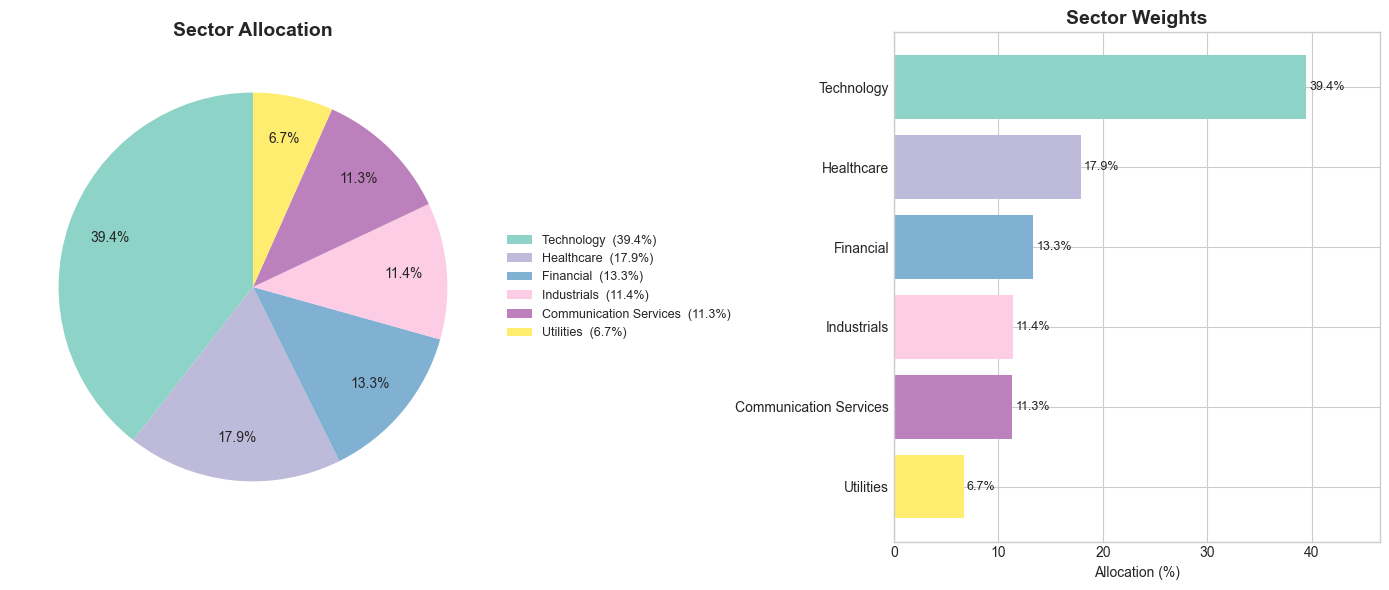

Saved: v4_sector_allocation.png


In [8]:
if portfolio is not None:
    sec_col = next((c for c in ['sector','Sector'] if c in portfolio.columns), None)
    if sec_col is None:
        print("No sector column ? skipping.")
    else:
        sa     = portfolio.groupby(sec_col)['weight'].sum().sort_values(ascending=False)
        colors = plt.cm.Set3(np.linspace(0, 1, len(sa)))

        fig, axes = plt.subplots(1, 2, figsize=(14, 6))
        wedges, _, _ = axes[0].pie(
            sa.values, labels=None, autopct=lambda p: f'{p:.1f}%' if p > 3 else '',
            colors=colors, startangle=90, pctdistance=0.78)
        axes[0].set_title('Sector Allocation', fontsize=14, fontweight='bold')
        axes[0].legend(wedges, [f'{s}  ({v*100:.1f}%)' for s,v in sa.items()],
                       loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)

        pct  = sa * 100
        bars = axes[1].barh(pct.index[::-1], pct.values[::-1], color=colors[::-1])
        axes[1].set_xlabel('Allocation (%)'); axes[1].set_title('Sector Weights', fontsize=14, fontweight='bold')
        axes[1].set_xlim(0, pct.max()*1.18)
        for bar, v in zip(bars, pct.values[::-1]):
            axes[1].text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)

        plt.tight_layout()
        plt.savefig(f'{REPORT_DIR}/v4_sector_allocation.png', dpi=150, bbox_inches='tight', facecolor='white')
        plt.show(); print("Saved: v4_sector_allocation.png")

## 5. Top Holdings

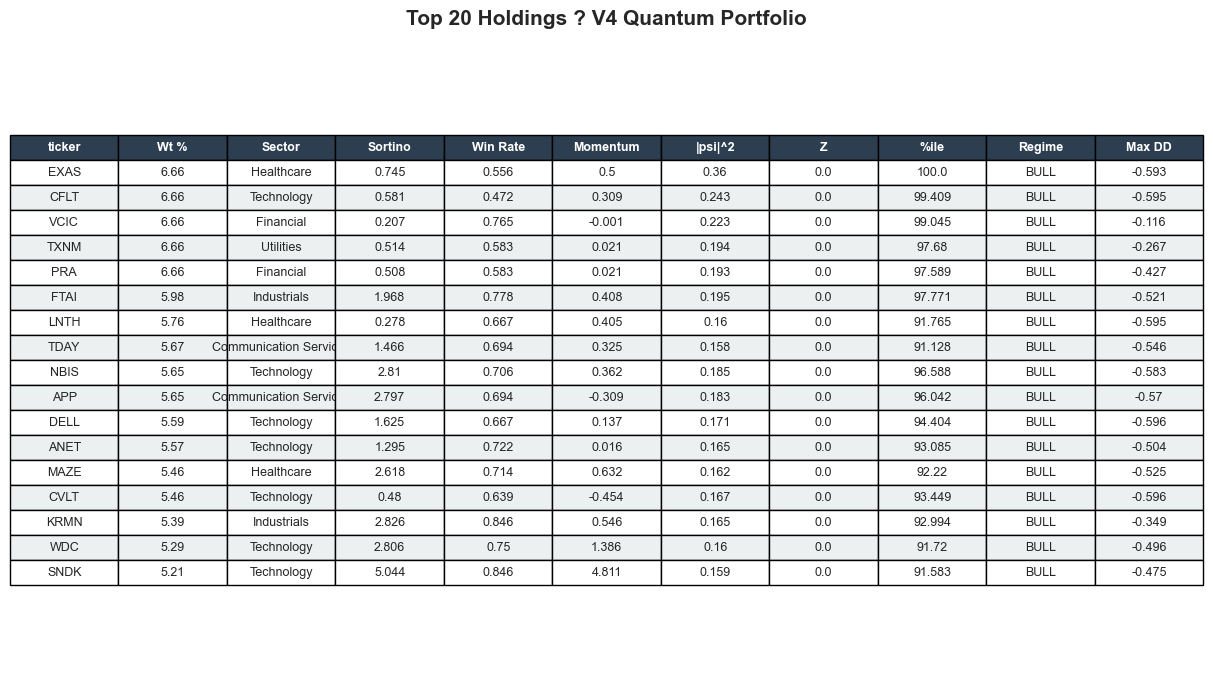

Saved: v4_top_holdings.png


In [9]:
if portfolio is not None:
    top20 = portfolio.nlargest(20, 'weight').copy()
    prefer = ['ticker','weight','sector','sortino','win_rate','momentum','psi_sq','zscore','psi_percentile','regime','max_dd']
    dcols  = [c for c in prefer if c in top20.columns]
    disp   = top20[dcols].copy()
    disp['weight'] = (disp['weight'] * 100).round(2)
    for col in disp.select_dtypes(include='float').columns: disp[col] = disp[col].round(3)
    rename = {'weight':'Wt %','sector':'Sector','sortino':'Sortino','win_rate':'Win Rate',
              'momentum':'Momentum','psi_sq':'|psi|^2','zscore':'Z','psi_percentile':'%ile',
              'regime':'Regime','max_dd':'Max DD'}
    disp = disp.rename(columns=rename)

    fig, ax = plt.subplots(figsize=(14, 8)); ax.axis('off')
    t = ax.table(cellText=disp.values, colLabels=disp.columns,
                 cellLoc='center', loc='center', colColours=['#2C3E50']*len(disp.columns))
    t.auto_set_font_size(False); t.set_fontsize(9); t.scale(1.1, 1.5)
    for j in range(len(disp.columns)): t[(0,j)].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(disp)+1):
        bg = '#ECF0F1' if i%2==0 else 'white'
        for j in range(len(disp.columns)): t[(i,j)].set_facecolor(bg)
    ax.set_title('Top 20 Holdings ? V4 Quantum Portfolio', fontsize=15, fontweight='bold', pad=20)
    plt.savefig(f'{REPORT_DIR}/v4_top_holdings.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_top_holdings.png")

## 6. Monte Carlo Simulation

In [10]:
def monte_carlo_simulation(ret_series, n_sims=1000, n_days=252, seed=42):
    mu = ret_series.mean(); sigma = ret_series.std()
    rng  = np.random.default_rng(seed)
    paths = rng.normal(mu, sigma, (n_sims, n_days))
    sims  = np.cumprod(1 + paths, axis=1)
    return sims, mu * 252, sigma * np.sqrt(252)

port_sims = spy_sims = None

if portfolio is not None and returns is not None:
    valid = [t for t in portfolio['ticker'].tolist() if t in returns.columns]
    wt    = portfolio.set_index('ticker').loc[valid,'weight'].values
    wt   /= wt.sum()
    port_daily = (returns[valid] * wt).sum(axis=1)

    port_sims, port_mu, port_sigma = monte_carlo_simulation(port_daily)
    print(f"Portfolio  E[R]: {port_mu*100:.1f}%  Vol: {port_sigma*100:.1f}%")

    if 'SPY' in returns.columns:
        spy_sims, spy_mu, spy_sigma = monte_carlo_simulation(returns['SPY'])
        print(f"SPY        E[R]: {spy_mu*100:.1f}%  Vol: {spy_sigma*100:.1f}%")

Portfolio  E[R]: 86.8%  Vol: 28.5%
SPY        E[R]: 18.4%  Vol: 18.9%


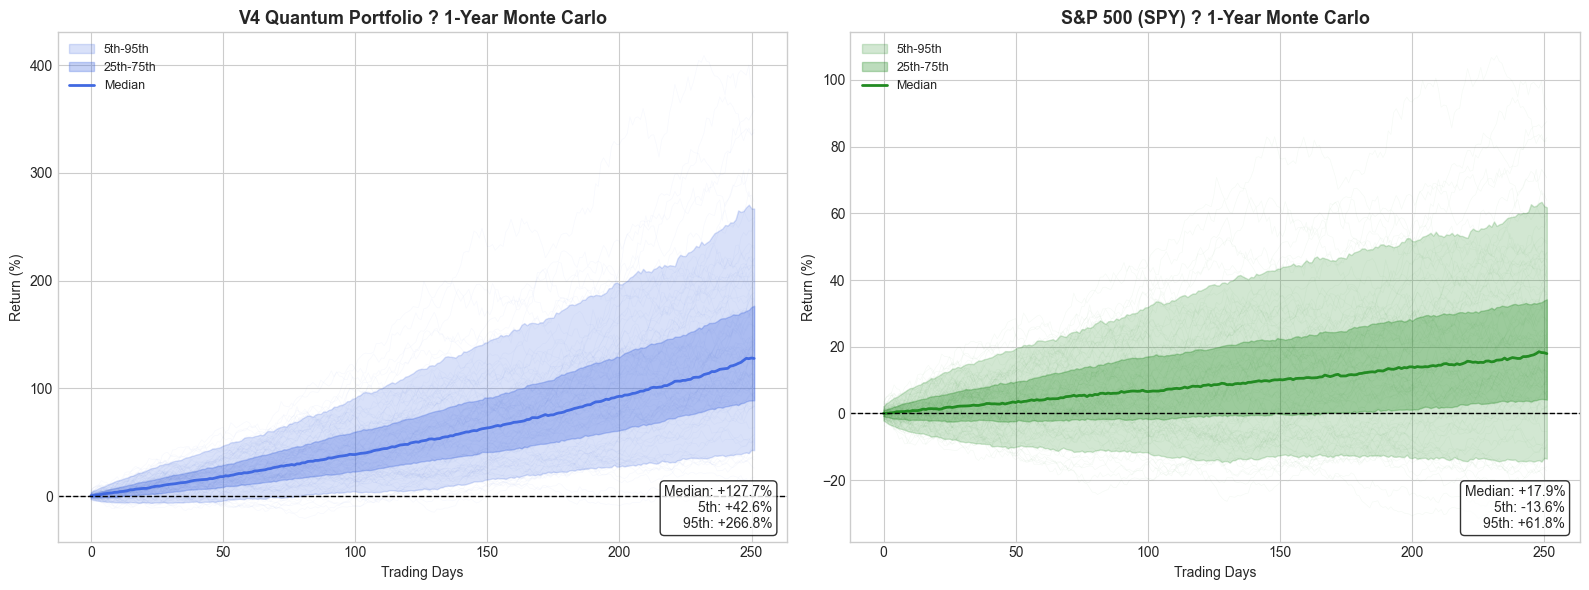

Saved: v4_monte_carlo.png


In [11]:
if port_sims is not None:
    days = np.arange(252)
    ncols = 2 if spy_sims is not None else 1
    fig, axes = plt.subplots(1, ncols, figsize=(8*ncols, 6))
    if ncols == 1: axes = [axes]

    def fan_ax(ax, sims, label, color):
        for i in range(min(80, len(sims))):
            ax.plot(days, (sims[i]-1)*100, alpha=0.04, color=color, linewidth=0.5)
        p5  = np.percentile(sims, 5,  axis=0)
        p25 = np.percentile(sims, 25, axis=0)
        p50 = np.percentile(sims, 50, axis=0)
        p75 = np.percentile(sims, 75, axis=0)
        p95 = np.percentile(sims, 95, axis=0)
        ax.fill_between(days, (p5-1)*100,  (p95-1)*100, alpha=0.20, color=color, label='5th-95th')
        ax.fill_between(days, (p25-1)*100, (p75-1)*100, alpha=0.30, color=color, label='25th-75th')
        ax.plot(days, (p50-1)*100, color=color, linewidth=2, label='Median')
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
        ax.set_xlabel('Trading Days'); ax.set_ylabel('Return (%)')
        ax.set_title(f'{label} ? 1-Year Monte Carlo', fontsize=13, fontweight='bold')
        ax.legend(fontsize=9)
        ax.text(0.98, 0.02,
                f'Median: {(p50[-1]-1)*100:+.1f}%\n5th: {(p5[-1]-1)*100:+.1f}%\n95th: {(p95[-1]-1)*100:+.1f}%',
                transform=ax.transAxes, fontsize=10, va='bottom', ha='right',
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

    fan_ax(axes[0], port_sims, 'V4 Quantum Portfolio', 'royalblue')
    if spy_sims is not None: fan_ax(axes[1], spy_sims, 'S&P 500 (SPY)', 'forestgreen')

    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/v4_monte_carlo.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_monte_carlo.png")

## 7. Portfolio vs S&P 500

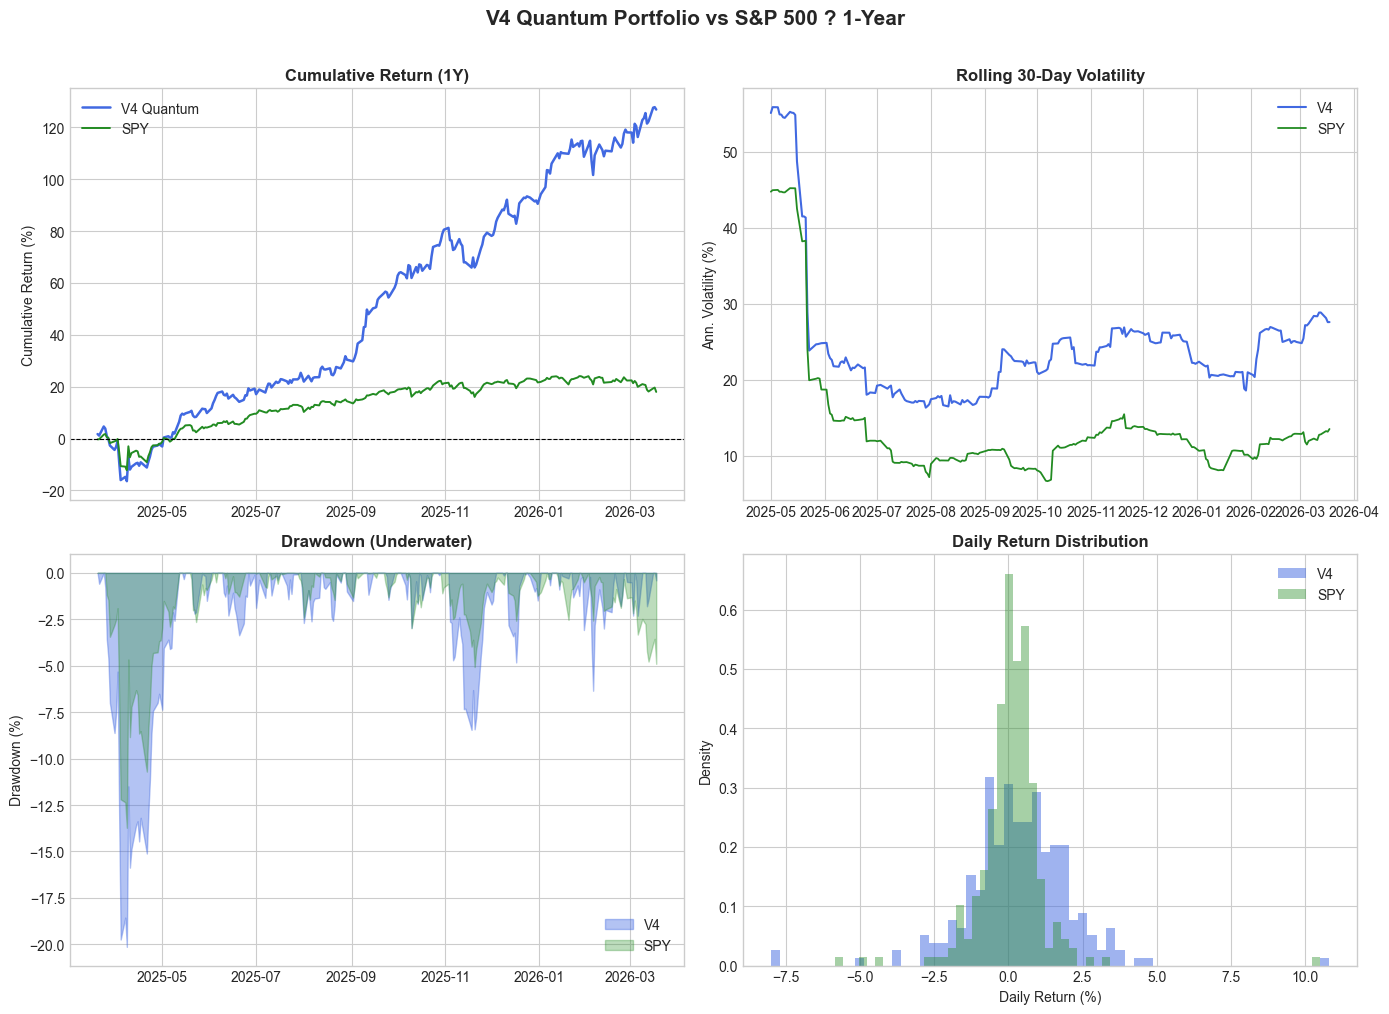

Saved: v4_vs_spy.png


In [12]:
if portfolio is not None and returns is not None and 'SPY' in returns.columns:
    valid = [t for t in portfolio['ticker'].tolist() if t in returns.columns]
    wt    = portfolio.set_index('ticker').loc[valid,'weight'].values; wt /= wt.sum()
    port_d = (returns[valid] * wt).sum(axis=1)
    spy_d  = returns['SPY']
    port_c = (1 + port_d).cumprod(); spy_c = (1 + spy_d).cumprod()

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0,0]
    ax.plot(port_c.index, (port_c-1)*100, label='V4 Quantum', color='royalblue', linewidth=1.8)
    ax.plot(spy_c.index,  (spy_c-1)*100,  label='SPY',         color='forestgreen', linewidth=1.4)
    ax.set_ylabel('Cumulative Return (%)'); ax.set_title('Cumulative Return (1Y)', fontweight='bold')
    ax.legend(); ax.axhline(0, color='black', linestyle='--', linewidth=0.8)

    ax = axes[0,1]
    ax.plot(port_d.rolling(30).std()*np.sqrt(252)*100, label='V4', color='royalblue', linewidth=1.5)
    ax.plot(spy_d.rolling(30).std()*np.sqrt(252)*100,  label='SPY', color='forestgreen', linewidth=1.3)
    ax.set_ylabel('Ann. Volatility (%)'); ax.set_title('Rolling 30-Day Volatility', fontweight='bold'); ax.legend()

    ax = axes[1,0]
    port_dd = (port_c / port_c.cummax() - 1)*100; spy_dd = (spy_c / spy_c.cummax() - 1)*100
    ax.fill_between(port_dd.index, port_dd, 0, alpha=0.4, color='royalblue',   label='V4')
    ax.fill_between(spy_dd.index,  spy_dd,  0, alpha=0.3, color='forestgreen', label='SPY')
    ax.set_ylabel('Drawdown (%)'); ax.set_title('Drawdown (Underwater)', fontweight='bold'); ax.legend()

    ax = axes[1,1]
    ax.hist(port_d*100, bins=60, alpha=0.5, color='royalblue',   label='V4',  density=True)
    ax.hist(spy_d*100,  bins=60, alpha=0.4, color='forestgreen', label='SPY', density=True)
    ax.set_xlabel('Daily Return (%)'); ax.set_ylabel('Density')
    ax.set_title('Daily Return Distribution', fontweight='bold'); ax.legend()

    plt.suptitle('V4 Quantum Portfolio vs S&P 500 ? 1-Year', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(f'{REPORT_DIR}/v4_vs_spy.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_vs_spy.png")

## 8. Risk Metrics

           Ann. Return Ann. Vol Sharpe Sortino  Max DD VaR 95% Win Rate Calmar
Strategy                                                                      
V4 Quantum       86.8%    28.5%   3.04    4.14  -20.1%  -2.24%    58.4%   4.31
SPY              18.4%    18.9%   0.98    1.24  -13.7%  -1.54%    56.0%   1.34


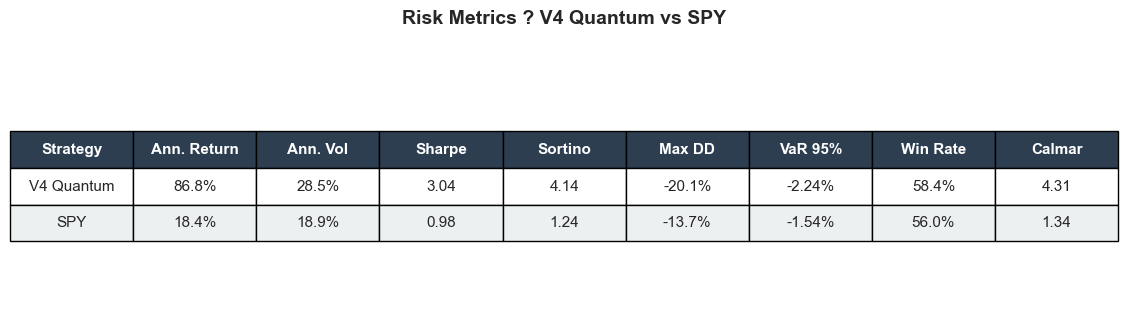

Saved: v4_risk_metrics.png


In [13]:
def calc_metrics(ret, name):
    ann_r = ret.mean()*252; ann_v = ret.std()*np.sqrt(252)
    sharpe = ann_r/ann_v if ann_v>0 else 0
    dn_std = ret[ret<0].std()*np.sqrt(252)
    sortino = ann_r/dn_std if dn_std>0 else 0
    cum = (1+ret).cumprod(); max_dd = (cum/cum.cummax()-1).min()
    var95 = np.percentile(ret, 5); win = (ret>0).mean()
    calmar = ann_r/abs(max_dd) if max_dd!=0 else 0
    return {'Strategy':name,'Ann. Return':f'{ann_r*100:.1f}%','Ann. Vol':f'{ann_v*100:.1f}%',
            'Sharpe':f'{sharpe:.2f}','Sortino':f'{sortino:.2f}','Max DD':f'{max_dd*100:.1f}%',
            'VaR 95%':f'{var95*100:.2f}%','Win Rate':f'{win*100:.1f}%','Calmar':f'{calmar:.2f}'}

if portfolio is not None and returns is not None:
    valid = [t for t in portfolio['ticker'].tolist() if t in returns.columns]
    wt    = portfolio.set_index('ticker').loc[valid,'weight'].values; wt /= wt.sum()
    port_d = (returns[valid] * wt).sum(axis=1)

    rows = [calc_metrics(port_d, 'V4 Quantum')]
    if 'SPY' in returns.columns: rows.append(calc_metrics(returns['SPY'], 'SPY'))
    mdf = pd.DataFrame(rows).set_index('Strategy')
    print(mdf.to_string())

    all_cols  = ['Strategy'] + list(mdf.columns)
    cell_data = [[idx] + list(row) for idx, row in zip(mdf.index, mdf.values)]
    fig, ax = plt.subplots(figsize=(13, 3.5)); ax.axis('off')
    t = ax.table(cellText=cell_data, colLabels=all_cols, cellLoc='center', loc='center',
                 colColours=['#2C3E50']*len(all_cols))
    t.auto_set_font_size(False); t.set_fontsize(11); t.scale(1.1, 2.2)
    for j in range(len(all_cols)): t[(0,j)].set_text_props(color='white', fontweight='bold')
    for i in range(1, len(cell_data)+1):
        bg = '#ECF0F1' if i%2==0 else 'white'
        for j in range(len(all_cols)): t[(i,j)].set_facecolor(bg)
    ax.set_title('Risk Metrics ? V4 Quantum vs SPY', fontsize=14, fontweight='bold', pad=20)
    plt.savefig(f'{REPORT_DIR}/v4_risk_metrics.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show(); print("Saved: v4_risk_metrics.png")

## 9. Full Composite Report

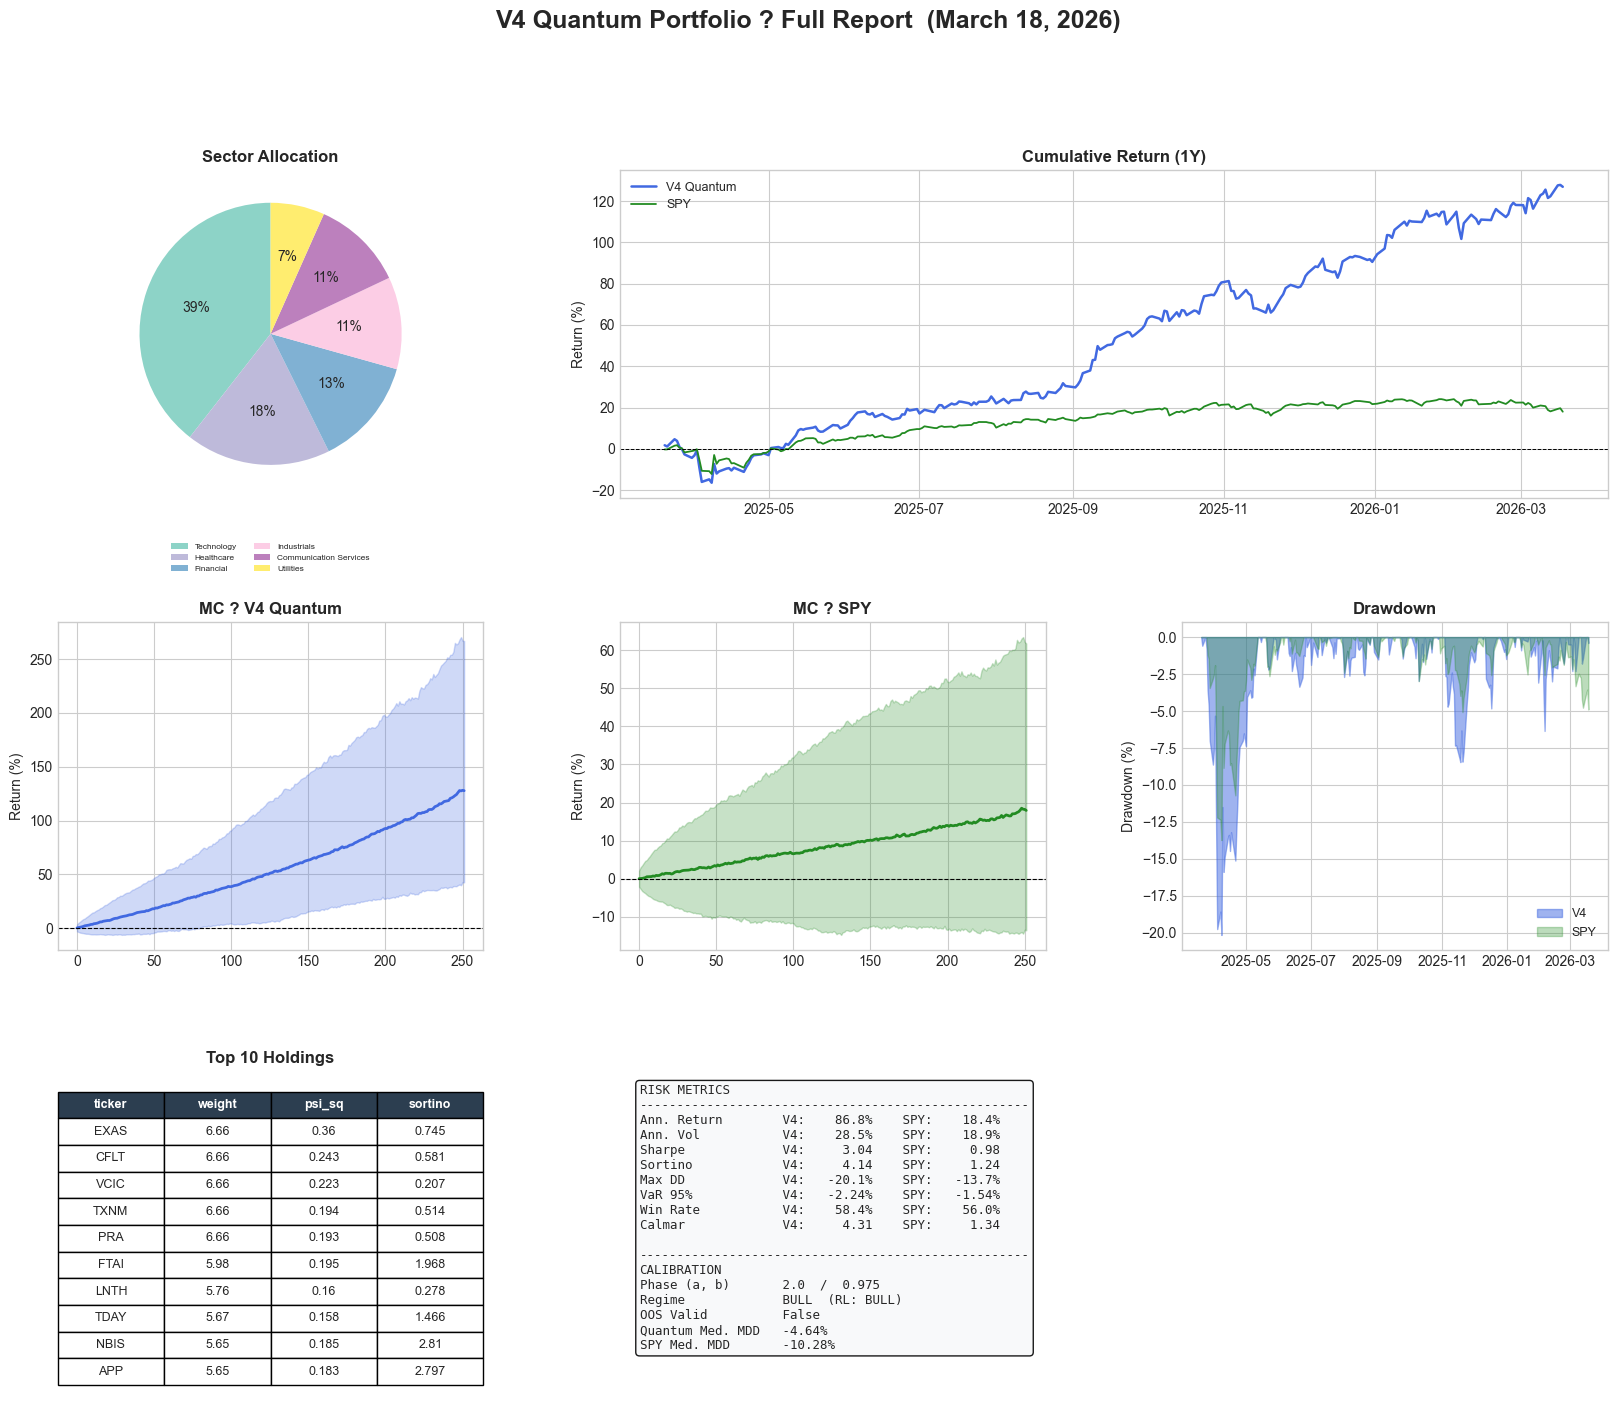


All reports saved to: c:\Users\maxim\OneDrive\Bureau\Python\v4_ultimate\output\v3\reports/
  v4_calibration_summary.png
  v4_full_report.png
  v4_monte_carlo.png
  v4_risk_metrics.png
  v4_sector_allocation.png
  v4_top_holdings.png
  v4_vs_spy.png
  v4_wave_amplitudes_report.png
  v4_zscore_signals_report.png


In [14]:
if portfolio is not None and returns is not None:
    valid = [t for t in portfolio['ticker'].tolist() if t in returns.columns]
    wt    = portfolio.set_index('ticker').loc[valid,'weight'].values; wt /= wt.sum()
    port_d = (returns[valid] * wt).sum(axis=1)
    port_c = (1 + port_d).cumprod()
    spy_c  = (1 + returns['SPY']).cumprod() if 'SPY' in returns.columns else None

    fig = plt.figure(figsize=(20, 16))
    fig.suptitle(f'V4 Quantum Portfolio ? Full Report  ({datetime.now().strftime("%B %d, %Y")})',
                 fontsize=18, fontweight='bold', y=0.98)
    gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.38, wspace=0.32)

    # Sector pie
    ax1 = fig.add_subplot(gs[0,0])
    sec_col = next((c for c in ['sector','Sector'] if c in portfolio.columns), None)
    if sec_col:
        sa = portfolio.groupby(sec_col)['weight'].sum().sort_values(ascending=False)
        cs = plt.cm.Set3(np.linspace(0,1,len(sa)))
        ax1.pie(sa.values, labels=None, colors=cs, startangle=90,
                autopct=lambda p: f'{p:.0f}%' if p>5 else '')
        ax1.set_title('Sector Allocation', fontweight='bold')
        ax1.legend(sa.index, loc='lower center', fontsize=6, ncol=2, bbox_to_anchor=(0.5,-0.25))

    # Cumulative return
    ax2 = fig.add_subplot(gs[0,1:])
    ax2.plot(port_c.index, (port_c-1)*100, label='V4 Quantum', color='royalblue', linewidth=1.8)
    if spy_c is not None: ax2.plot(spy_c.index, (spy_c-1)*100, label='SPY', color='forestgreen', linewidth=1.3)
    ax2.axhline(0, color='black', linestyle='--', linewidth=0.7)
    ax2.set_ylabel('Return (%)'); ax2.set_title('Cumulative Return (1Y)', fontweight='bold'); ax2.legend(fontsize=9)

    # MC Portfolio
    ax3 = fig.add_subplot(gs[1,0])
    days = np.arange(252)
    if port_sims is not None:
        p5  = np.percentile(port_sims, 5, axis=0)
        p50 = np.percentile(port_sims,50, axis=0)
        p95 = np.percentile(port_sims,95, axis=0)
        ax3.fill_between(days,(p5-1)*100,(p95-1)*100,alpha=0.25,color='royalblue')
        ax3.plot(days,(p50-1)*100,color='royalblue',linewidth=2)
        ax3.axhline(0,color='black',linestyle='--',linewidth=0.8)
    ax3.set_ylabel('Return (%)'); ax3.set_title('MC ? V4 Quantum', fontweight='bold')

    # MC SPY
    ax4 = fig.add_subplot(gs[1,1])
    if spy_sims is not None:
        p5  = np.percentile(spy_sims, 5, axis=0)
        p50 = np.percentile(spy_sims,50, axis=0)
        p95 = np.percentile(spy_sims,95, axis=0)
        ax4.fill_between(days,(p5-1)*100,(p95-1)*100,alpha=0.25,color='forestgreen')
        ax4.plot(days,(p50-1)*100,color='forestgreen',linewidth=2)
        ax4.axhline(0,color='black',linestyle='--',linewidth=0.8)
    ax4.set_ylabel('Return (%)'); ax4.set_title('MC ? SPY', fontweight='bold')

    # Drawdown
    ax5 = fig.add_subplot(gs[1,2])
    dd_p = (port_c/port_c.cummax()-1)*100
    ax5.fill_between(dd_p.index, dd_p, 0, alpha=0.5, color='royalblue', label='V4')
    if spy_c is not None:
        dd_s = (spy_c/spy_c.cummax()-1)*100
        ax5.fill_between(dd_s.index, dd_s, 0, alpha=0.3, color='forestgreen', label='SPY')
    ax5.set_ylabel('Drawdown (%)'); ax5.set_title('Drawdown', fontweight='bold'); ax5.legend(fontsize=9)

    # Top 10 table
    ax6 = fig.add_subplot(gs[2,0]); ax6.axis('off')
    t10_cols = [c for c in ['ticker','weight','psi_sq','sortino'] if c in portfolio.columns]
    top10 = portfolio.nlargest(10,'weight')[t10_cols].copy()
    top10['weight'] = (top10['weight']*100).round(2)
    for col in top10.select_dtypes('float').columns: top10[col] = top10[col].round(3)
    t6 = ax6.table(cellText=top10.values, colLabels=top10.columns, cellLoc='center', loc='center',
                   colColours=['#2C3E50']*len(top10.columns))
    t6.auto_set_font_size(False); t6.set_fontsize(9); t6.scale(1.0, 1.6)
    for j in range(len(top10.columns)): t6[(0,j)].set_text_props(color='white', fontweight='bold')
    ax6.set_title('Top 10 Holdings', fontweight='bold', pad=8)

    # Risk metrics text
    ax7 = fig.add_subplot(gs[2,1:]); ax7.axis('off')
    m = calc_metrics(port_d, 'V4 Quantum')
    sm = calc_metrics(returns['SPY'], 'SPY') if spy_c is not None else {}
    lines = ['RISK METRICS', '-'*52]
    for k in ['Ann. Return','Ann. Vol','Sharpe','Sortino','Max DD','VaR 95%','Win Rate','Calmar']:
        lines.append(f'{k:<18} V4: {m.get(k,"N/A"):>8}    SPY: {sm.get(k,"N/A"):>8}')
    if cal_meta:
        dd_mc = cal_meta.get('drawdown',{})
        lines += ['', '-'*52, 'CALIBRATION']
        lines.append(f'Phase (a, b)       {cal_meta.get("best_a")}  /  {cal_meta.get("best_b")}')
        lines.append(f'Regime             {cal_meta.get("regime")}  (RL: {cal_meta.get("rl_recommended")})')
        lines.append(f'OOS Valid          {cal_meta.get("oos_valid")}')
        lines.append(f'Quantum Med. MDD   {dd_mc.get("quantum_median_mdd","N/A")}%')
        lines.append(f'SPY Med. MDD       {dd_mc.get("spy_median_mdd","N/A")}%')
    ax7.text(0.02, 0.97, '\n'.join(lines), transform=ax7.transAxes,
             fontsize=9, va='top', ha='left', fontfamily='monospace',
             bbox=dict(boxstyle='round', facecolor='#F8F9FA', alpha=0.9))

    plt.savefig(f'{REPORT_DIR}/v4_full_report.png', dpi=150, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"\nAll reports saved to: {os.path.abspath(REPORT_DIR)}/")
    for f in sorted(os.listdir(REPORT_DIR)):
        if f.endswith('.png'): print(f"  {f}")

## Appendix: V4 Notebook Charts

Charts generated by the main `StockPickerV4_Ultimate.ipynb` notebook (copied here for reference).

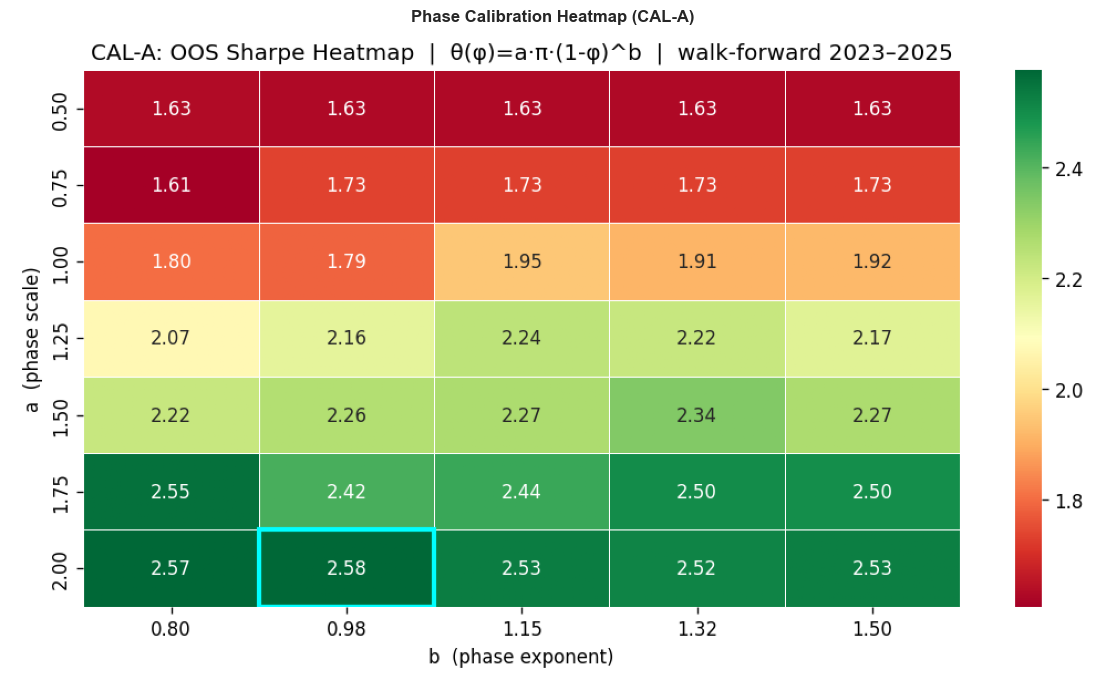

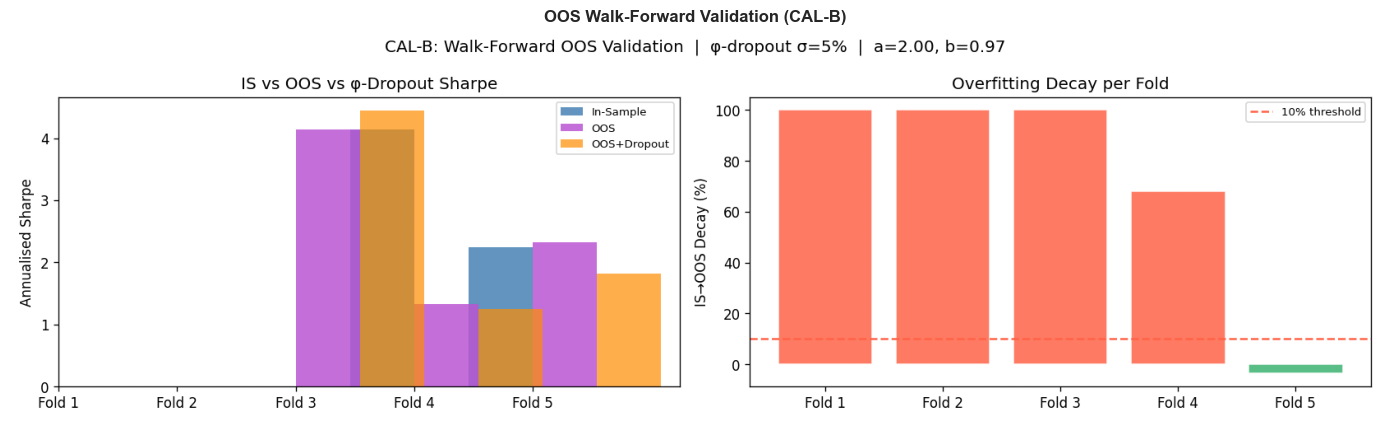

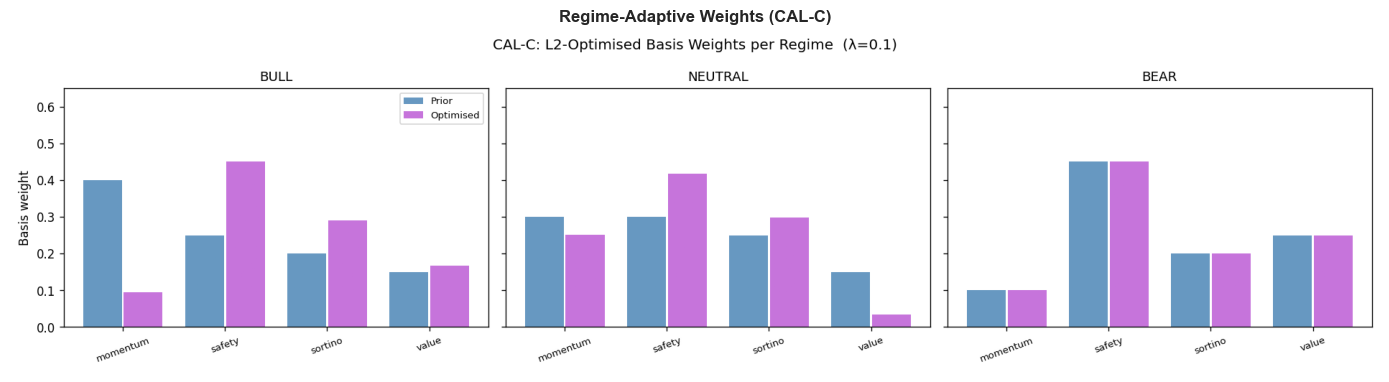

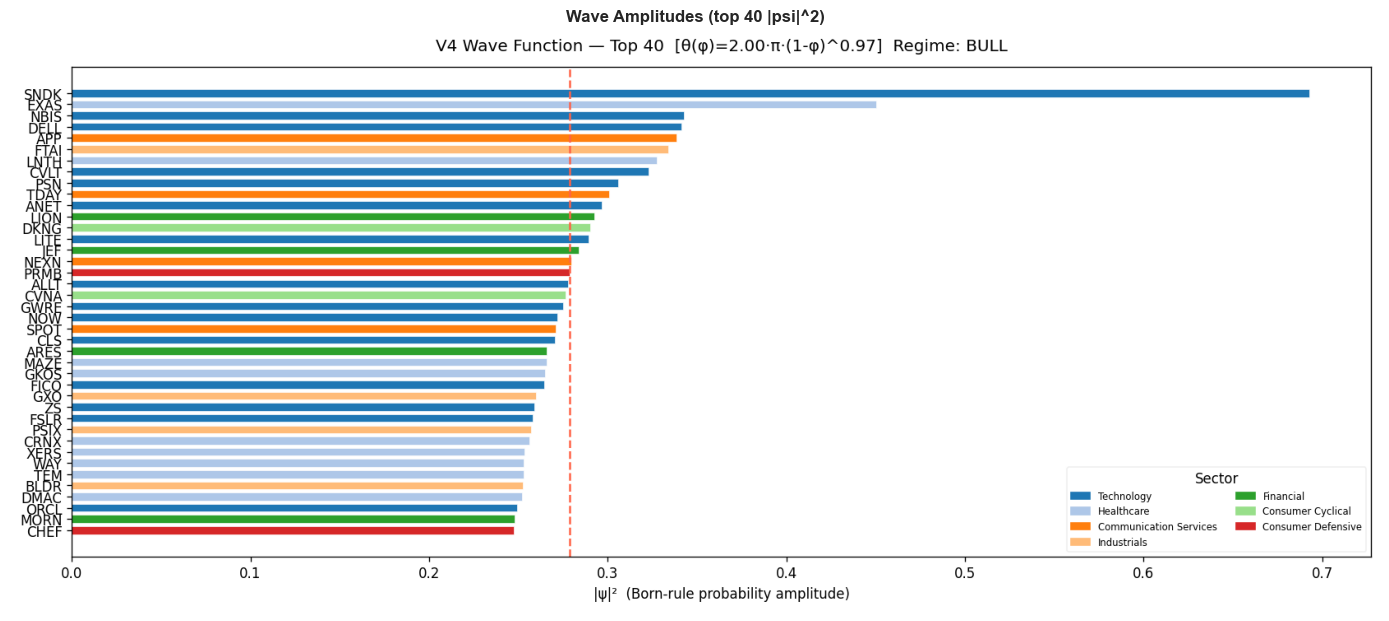

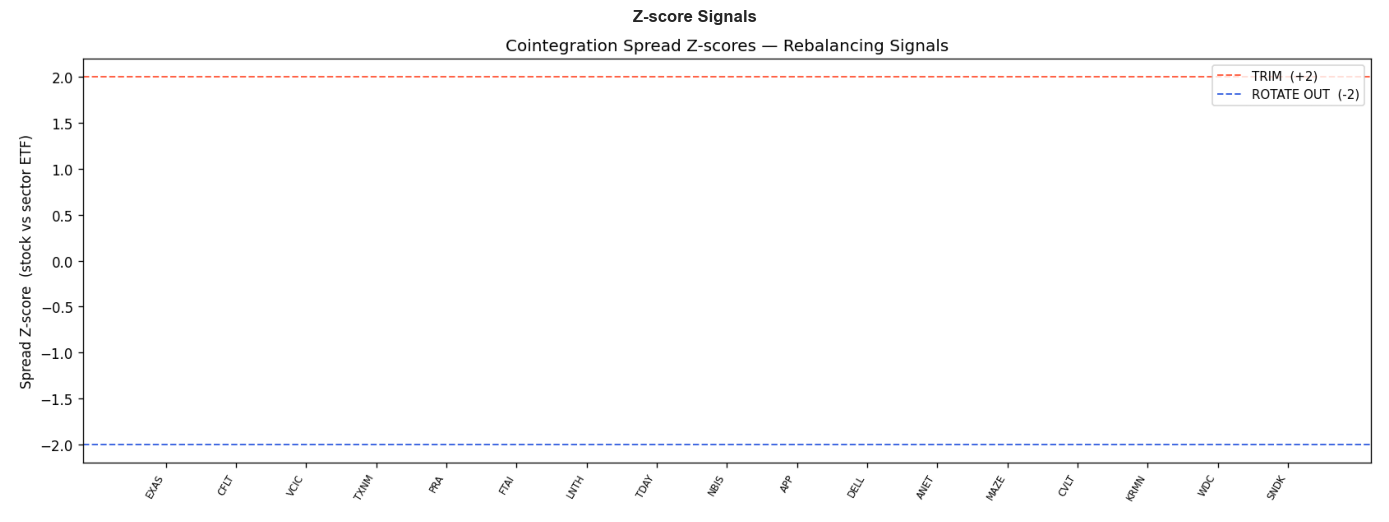

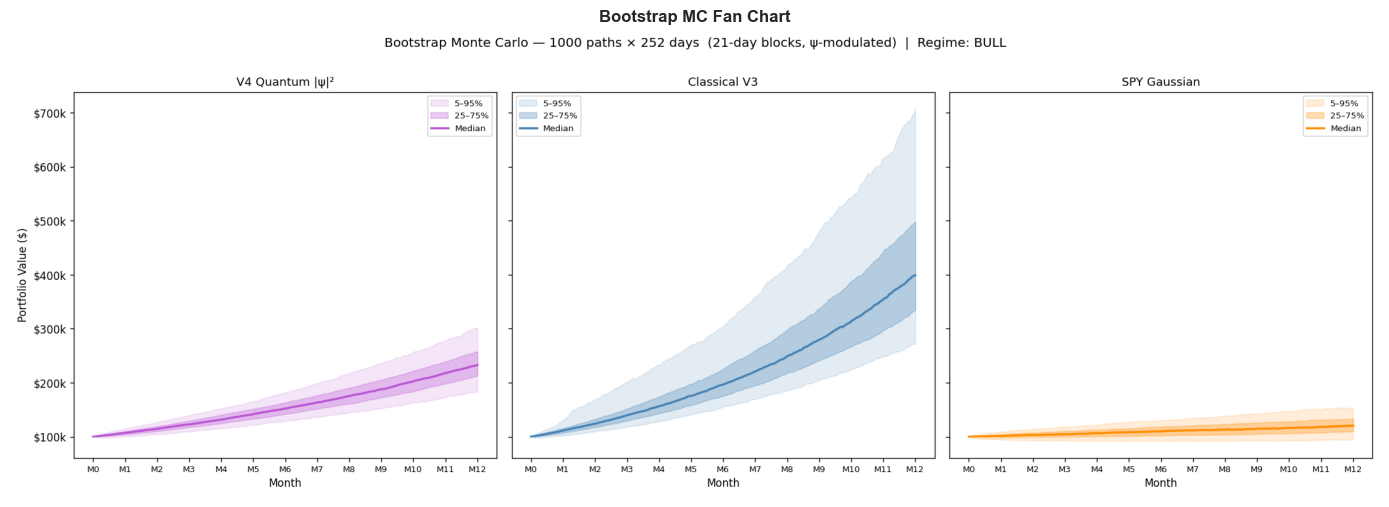

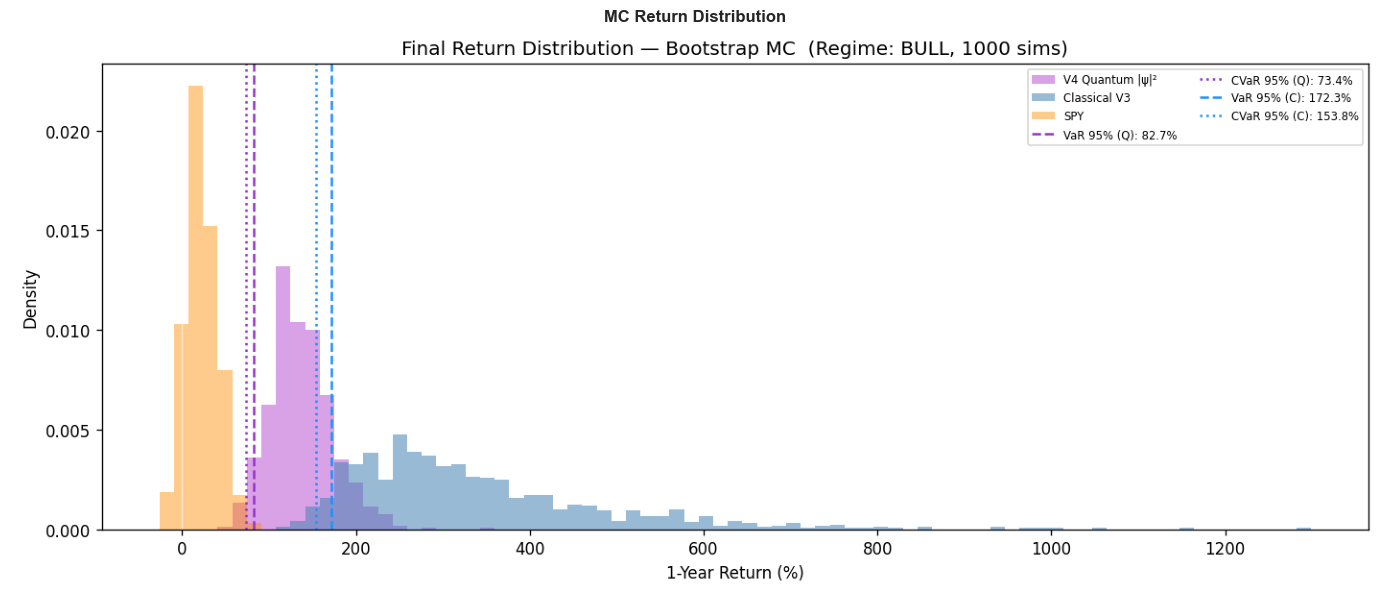

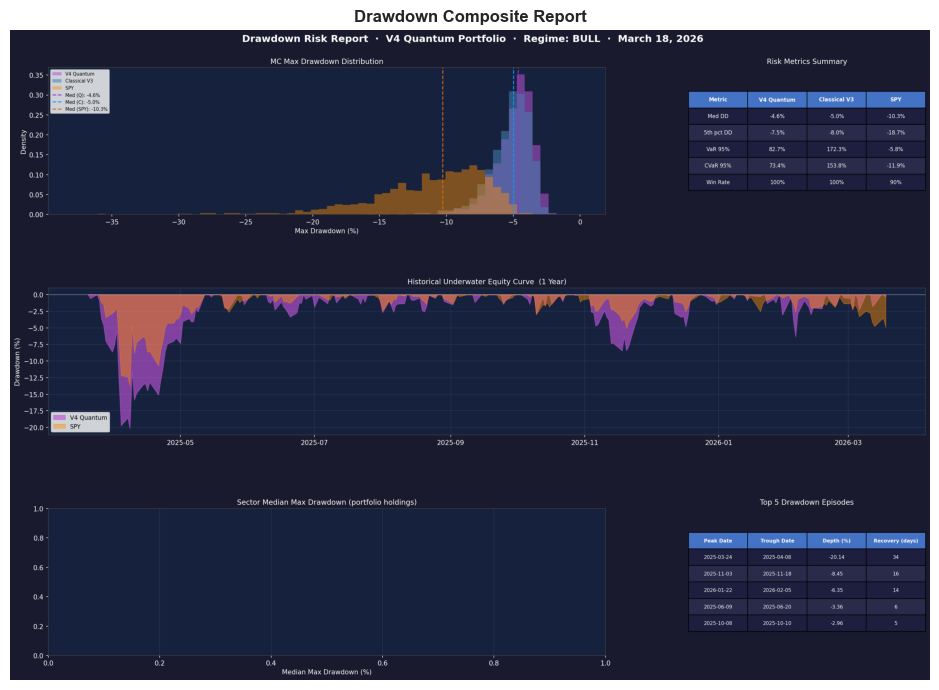

In [15]:
# Display pre-generated V4 charts from the notebook output
v4_charts = [
    ('v4_phase_calibration_heatmap.png', 'Phase Calibration Heatmap (CAL-A)'),
    ('v4_oos_validation.png',            'OOS Walk-Forward Validation (CAL-B)'),
    ('v4_regime_weights_optimised.png',  'Regime-Adaptive Weights (CAL-C)'),
    ('v4_wave_amplitudes.png',           'Wave Amplitudes (top 40 |psi|^2)'),
    ('v4_zscore_signals.png',            'Z-score Signals'),
    ('v4_mc_fan_chart.png',              'Bootstrap MC Fan Chart'),
    ('v4_mc_return_dist.png',            'MC Return Distribution'),
    ('v4_drawdown_report.png',           'Drawdown Composite Report'),
]
import matplotlib.image as mpimg
for fname, title in v4_charts:
    fpath = f'../output/v3/{fname}'
    if os.path.exists(fpath):
        fig, ax = plt.subplots(figsize=(14, 7))
        ax.imshow(mpimg.imread(fpath))
        ax.axis('off'); ax.set_title(title, fontsize=12, fontweight='bold')
        plt.tight_layout(); plt.show()
    else:
        print(f"Not found: {fpath}  (run StockPickerV4_Ultimate.ipynb first)")